# Week-1

# Linear Regression Example using tensorflow
Linear regression implementation with TensorFlow v2 library.

This example is using a low-level approach to better understand all mechanics behind the training process.


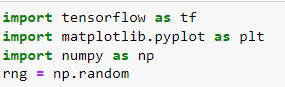

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
rng = np.random

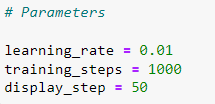

In [2]:
# Parameters

learning_rate = 0.01
training_steps = 1000
display_step = 50

#### Just run the next cell using 'Ctrl' + 'Enter'

In [3]:
# Training Data.

X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])

Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])

n_samples = X.shape[0]

In [5]:
print(X,'\n' ,X.shape)

[ 3.3    4.4    5.5    6.71   6.93   4.168  9.779  6.182  7.59   2.167
  7.042 10.791  5.313  7.997  5.654  9.27   3.1  ] 
 (17,)


[ 3.3    4.4    5.5    6.71   6.93   4.168  9.779  6.182  7.59   2.167
  7.042 10.791  5.313  7.997  5.654  9.27   3.1  ] 
 (17,)


[1.7   2.76  2.09  3.19  1.694 1.573 3.366 2.596 2.53  1.221 2.827 3.465
 1.65  2.904 2.42  2.94  1.3  ] 
 (17,)


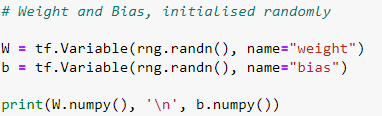

In [6]:
# Weight and Bias, initialised randomly

W = tf.Variable(rng.randn(), name="weight")
b = tf.Variable(rng.randn(), name="bias")

print(W.numpy(), '\n', b.numpy())

-1.2990683 
 -0.4204261


-0.6282028 
 1.6282653


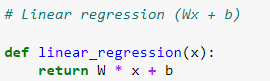

In [7]:
# Linear regression (Wx + b)

def linear_regression(x):
    return W * x + b

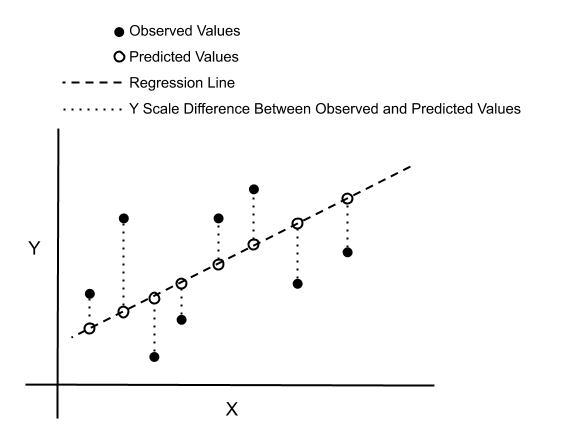

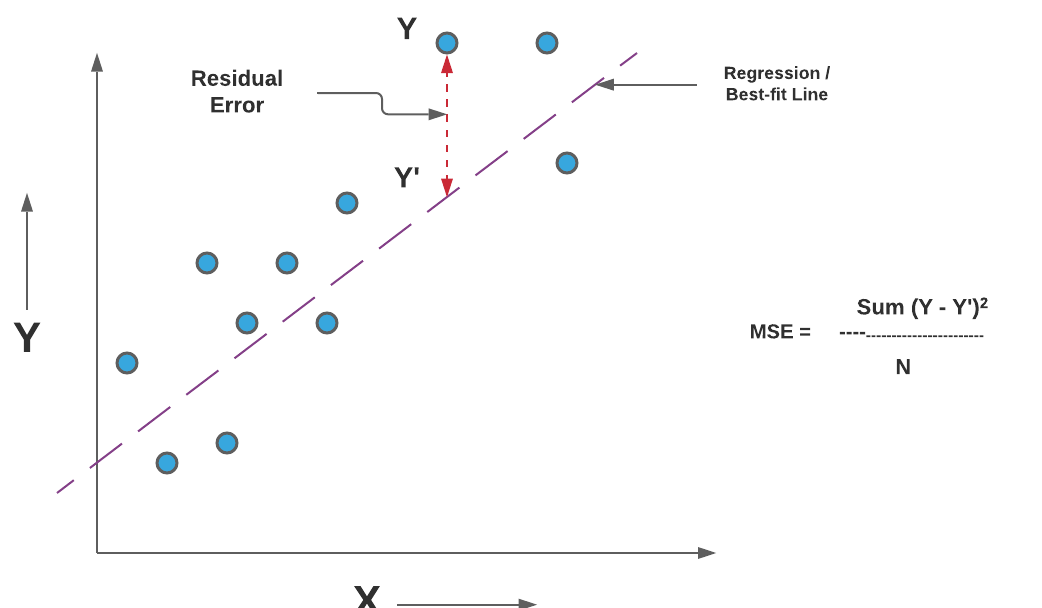

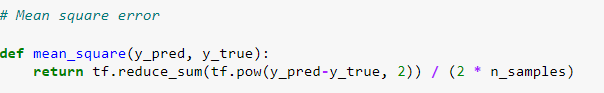

In [8]:
# Mean square error

def mean_square(y_pred, y_true):
    return tf.reduce_sum(tf.pow(y_pred-y_true, 2)) / (2 * n_samples)

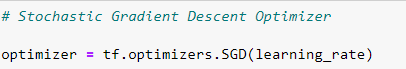

In [9]:
# Stochastic Gradient Descent Optimizer

optimizer = tf.optimizers.SGD(learning_rate)

In [ ]:
# Adding a question mark () after the function name lets you view the latest documentation. 
# This is a handy tool.

In [10]:
tf.optimizers.SGD?

Init signature:
tf.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.0,
    nesterov=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='SGD',
    **kwargs,
)
Docstring:     
Gradient descent (with momentum) optimizer.

Update rule for parameter `w` with gradient `g` when `momentum` is 0:

```python
w = w - learning_rate * g
```

Update rule when `momentum` is larger than 0:

```python
velocity = momentum * velocity - learning_rate * g
w = w + velocity
```

When `nesterov=True`, this rule becomes:

```python
velocity = momentum * velocity - learning_rate * g
w = w + momentum * velocity - learning_rate * g
```

Args:
    learning_rate: A float, a
        `keras.optimizers.schedules.LearningRateSchedule` instance, or
        a callable that takes no arguments and returns the actual value to


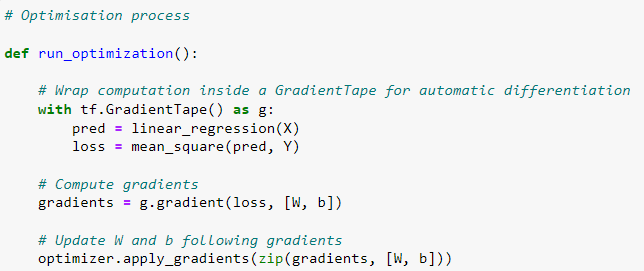

In [11]:
# Optimisation process
def run_optimization():

    # Wrap computation inside a GradientTape for automatic differentiation
    with tf.GradientTape() as g:
        pred = linear_regression(X)
        loss = mean_square(pred, Y)

    # Compute gradients
    gradients = g.gradient(loss, [W, b])

    # Update W and b following gradients
    optimizer.apply_gradients(zip(gradients, [W, b]))

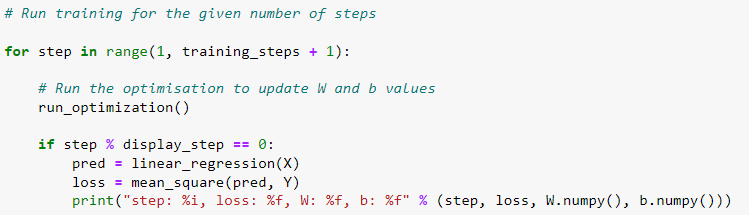

In [12]:
# Run training for the given number of steps

for step in range(1, training_steps + 1):

    # Run the optimisation to update W and b values
    run_optimization()

    if step % display_step == 0:
        pred = linear_regression(X)
        loss = mean_square(pred, Y)
        print("step: %i, loss: %f, W: %f, b: %f" % (step, loss, W.numpy(), b.numpy()))

step: 50, loss: 0.129683, W: 0.381852, b: -0.124377
step: 100, loss: 0.123649, W: 0.374179, b: -0.069983
step: 150, loss: 0.118306, W: 0.366959, b: -0.018793
step: 200, loss: 0.113574, W: 0.360164, b: 0.029380
step: 250, loss: 0.109382, W: 0.353769, b: 0.074716
step: 300, loss: 0.105671, W: 0.347751, b: 0.117379
step: 350, loss: 0.102383, W: 0.342088, b: 0.157530
step: 400, loss: 0.099472, W: 0.336758, b: 0.195314
step: 450, loss: 0.096894, W: 0.331743, b: 0.230872
step: 500, loss: 0.094611, W: 0.327023, b: 0.264335
step: 550, loss: 0.092588, W: 0.322581, b: 0.295827
step: 600, loss: 0.090797, W: 0.318401, b: 0.325462
step: 650, loss: 0.089211, W: 0.314467, b: 0.353352
step: 700, loss: 0.087806, W: 0.310765, b: 0.379599
step: 750, loss: 0.086562, W: 0.307281, b: 0.404298
step: 800, loss: 0.085461, W: 0.304002, b: 0.427543
step: 850, loss: 0.084485, W: 0.300916, b: 0.449418
step: 900, loss: 0.083621, W: 0.298013, b: 0.470004
step: 950, loss: 0.082855, W: 0.295280, b: 0.489377
step: 1000

step: 50, loss: 0.124850, W: 0.127526, b: 1.678677
step: 100, loss: 0.119369, W: 0.134839, b: 1.626834
step: 150, loss: 0.114515, W: 0.141720, b: 1.578046
step: 200, loss: 0.110216, W: 0.148197, b: 1.532132
step: 250, loss: 0.106409, W: 0.154291, b: 1.488923
step: 300, loss: 0.103038, W: 0.160027, b: 1.448260
step: 350, loss: 0.100052, W: 0.165425, b: 1.409994
step: 400, loss: 0.097407, W: 0.170504, b: 1.373981
step: 450, loss: 0.095065, W: 0.175285, b: 1.340091
step: 500, loss: 0.092991, W: 0.179783, b: 1.308198
step: 550, loss: 0.091154, W: 0.184017, b: 1.278184
step: 600, loss: 0.089527, W: 0.188001, b: 1.249938
step: 650, loss: 0.088086, W: 0.191750, b: 1.223357
step: 700, loss: 0.086810, W: 0.195279, b: 1.198342
step: 750, loss: 0.085680, W: 0.198599, b: 1.174800
step: 800, loss: 0.084679, W: 0.201724, b: 1.152646
step: 850, loss: 0.083793, W: 0.204665, b: 1.131797
step: 900, loss: 0.083008, W: 0.207432, b: 1.112177
step: 950, loss: 0.082312, W: 0.210037, b: 1.093712
step: 1000, l

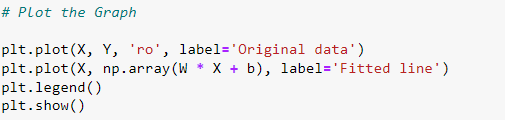

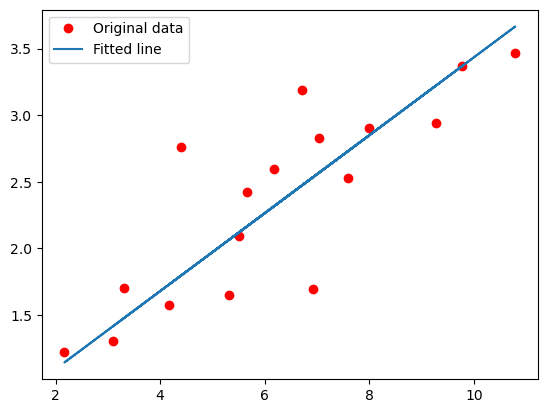

In [16]:
# Plot the Graph

plt.plot(X, Y, 'ro', label='Original data')
plt.plot(X, np.array(W * X + b), label='Fitted line')
plt.legend()
plt.show()

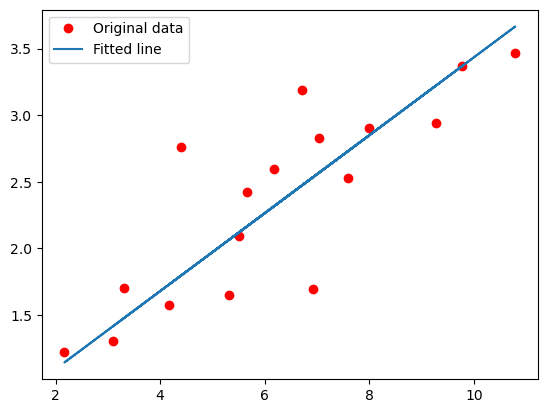

In [15]:
# Plot the Graph

plt.plot(X, Y, 'ro', label='Original data')
plt.plot(X, np.array(W * X + b), label='Fitted line')
plt.legend()
plt.show()

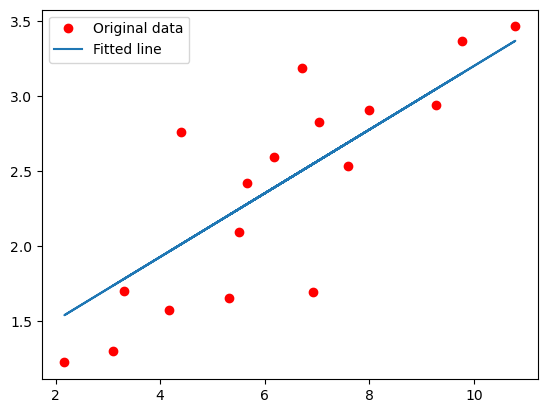

# Lab Logbook requirements: 
### Please make sure to document the following in your Lablogbook:

Include an image of the generated graph depicting the original data and the fitted line for linear regression. Modify the appearance of the graph by adjusting its color or size. Copy the figure and paste it directly into your logbook. Refrain from taking a snapshot; instead, right-click and copy the graph to your lab logbook. Ensure that no code or other information is added to the logbook and that only required graph is present.  

#### Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.